# Лабораторная работа №3. Обработка цифровых сигналов
**Вариант №3:** КИХ – окно Блэкмана, БИХ – Чебышёва 1, режекторный фильтр (РФ).  
Все алгоритмы реализованы вручную (ДПФ, фильтрация) с обязательным сравнением.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, cheby1, freqz
import pywt
import time

FIG_DIR = Path("figures_lab3")
FIG_DIR.mkdir(exist_ok=True)

def save_figure(fig, name, dpi=300):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Рисунок сохранён: {FIG_DIR / (name + '.png')}")

# Параметры сигнала (согласно методичке)
fs = 40       # частота дискретизации, Гц
T = 1/fs       # период, с (0.025 с)
data = np.loadtxt('signal_3.txt')
N = len(data)  # 400 отсчётов
t = np.arange(N) * T   # вектор времени от 0 до 10 с

print(f"Отсчётов: {N}, длительность: {N*T:.2f} с, период дискретизации: {T:.3f} с")



Отсчётов: 400, длительность: 10.00 с, период дискретизации: 0.025 с


## 1. Дискретное преобразование Фурье (ДПФ)

ДПФ ставит в соответствие $N$ временны́м отсчётам $x(n)$ последовательность комплексных спектральных коэффициентов $X(m)$:

$$X(m) = \sum_{n=0}^{N-1} x(n) e^{-j\frac{2\pi n m}{N}}, \quad m = 0,1,\dots,N-1$$

Обратное преобразование (ОДПФ) позволяет восстановить сигнал:

$$x(n) = \frac{1}{N} \sum_{m=0}^{N-1} X(m) e^{j\frac{2\pi n m}{N}}.$$

Уникальная информация содержится до частоты Найквиста $f_N = f_s/2-1$.  
Амплитудный спектр вычисляется как $|X(m)|$, для гармоник (кроме постоянной составляющей) применяется нормировка $2/N$, для постоянной – $1/N$.  
Фаза определяется через $\arg(X(m))$ и относится к **косинусному** представлению.  
Ниже приведена ручная реализация ДПФ, результаты которой сравниваются с библиотечной `numpy.fft.fft`.

Макс. расхождение между ручным и numpy.fft: 3.4977528982565345e-10
Рисунок сохранён: figures_lab3/manual_dft_spectrum.png


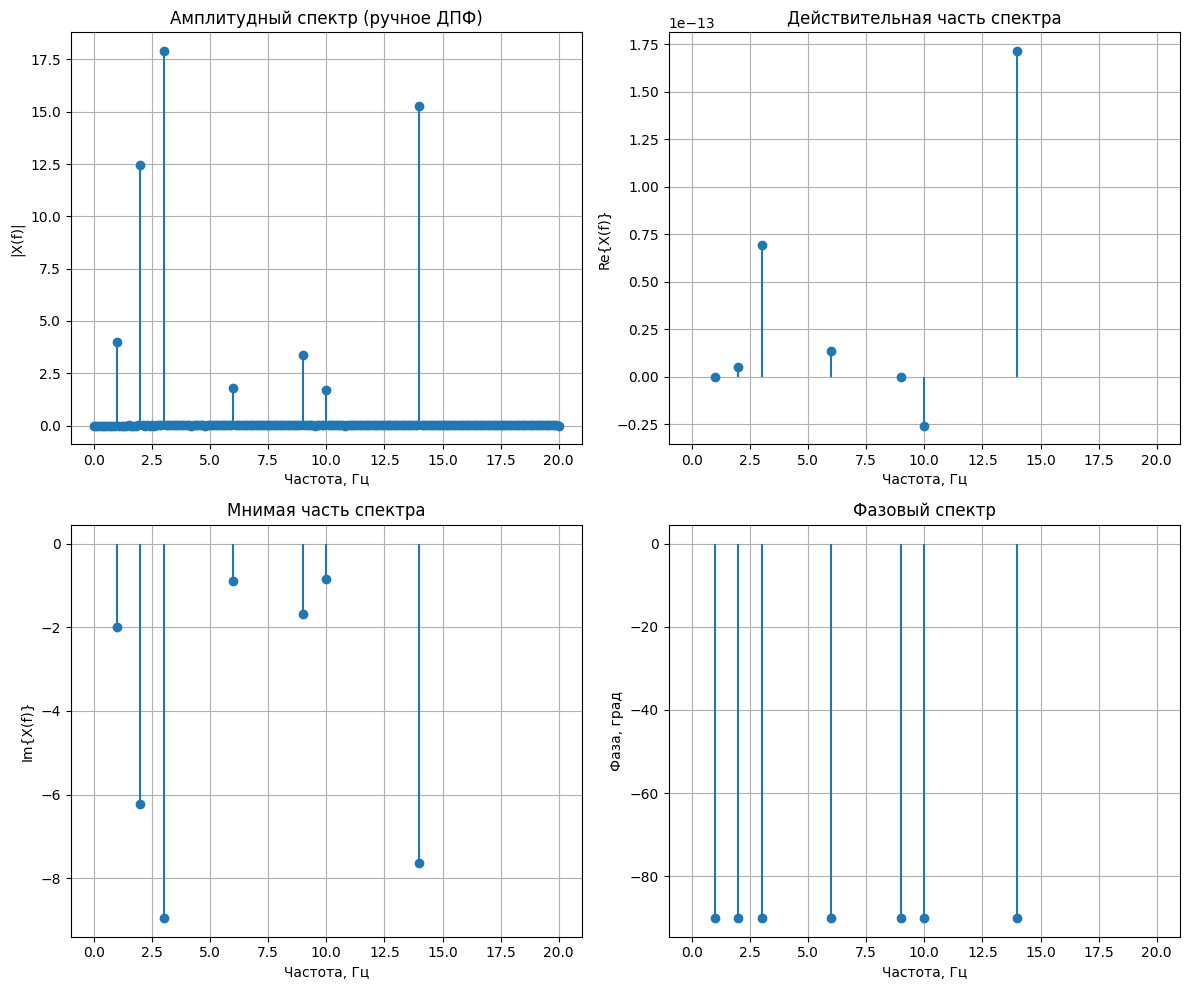

In [2]:
# ------------------------------------------------------------
# Ручное ДПФ (формула 3.1)
# ------------------------------------------------------------
def manual_dft(x):
    x = np.asarray(x, dtype=float)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

# Сигнал
x = np.asarray(data, dtype=float)
N = len(x)

# ВАЖНО:
# dt — это шаг дискретизации по времени.
# Если у тебя уже есть временная ось t, то лучше взять:
# dt = t[1] - t[0]
#
# Если переменная T у тебя означает именно шаг дискретизации,
# тогда оставляем так:
dt = T

# Ручное ДПФ и библиотечное для проверки
X_manual = manual_dft(x)
X_lib = np.fft.fft(x)

# Проверка совпадения
print("Макс. расхождение между ручным и numpy.fft:",
      np.max(np.abs(X_manual - X_lib)))

# ------------------------------------------------------------
# Частотная ось и спектральные характеристики
# ------------------------------------------------------------

# Нормированный спектр
Xn = X_manual / N

# Берём только неотрицательные частоты
freqs = np.fft.rfftfreq(N, d=dt)
X_pos = Xn[:len(freqs)]

# Односторонний амплитудный спектр
amp = np.abs(X_pos).copy()

if N % 2 == 0:
    # если N чётное, последний отсчёт — частота Найквиста
    if len(amp) > 2:
        amp[1:-1] *= 2
else:
    # если N нечётное
    if len(amp) > 1:
        amp[1:] *= 2

# Действительная и мнимая части
real_part = np.real(X_pos)
imag_part = np.imag(X_pos)

# Фаза
phase = np.angle(X_pos, deg=True)

# ------------------------------------------------
# Убираем шумовые компоненты
# ------------------------------------------------
threshold = np.max(amp) * 0.01
mask = amp < threshold

real_part[mask] = np.nan
imag_part[mask] = np.nan
phase[mask] = np.nan

# ------------------------------------------------------------
# Графики
# ------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1. Амплитудный спектр
axs[0, 0].stem(freqs, amp, basefmt=" ")
axs[0, 0].set_title("Амплитудный спектр (ручное ДПФ)")
axs[0, 0].set_xlabel("Частота, Гц")
axs[0, 0].set_ylabel("|X(f)|")
axs[0, 0].grid(True)

# 2. Действительная часть
axs[0, 1].stem(freqs, real_part, basefmt=" ")
axs[0, 1].set_title("Действительная часть спектра")
axs[0, 1].set_xlabel("Частота, Гц")
axs[0, 1].set_ylabel("Re{X(f)}")
axs[0, 1].grid(True)

# 3. Мнимая часть
axs[1, 0].stem(freqs, imag_part, basefmt=" ")
axs[1, 0].set_title("Мнимая часть спектра")
axs[1, 0].set_xlabel("Частота, Гц")
axs[1, 0].set_ylabel("Im{X(f)}")
axs[1, 0].grid(True)

# 4. Фаза
axs[1, 1].stem(freqs, phase, basefmt=" ")
axs[1, 1].set_title("Фазовый спектр")
axs[1, 1].set_xlabel("Частота, Гц")
axs[1, 1].set_ylabel("Фаза, град")
axs[1, 1].grid(True)

plt.tight_layout()
save_figure(fig, "manual_dft_spectrum")
plt.show()

## 2. Аналитическое уравнение сигнала

По амплитудному спектру выделяются доминирующие гармоники.  
Исходное представление через косинус $A_k \cos(2\pi f_k t + \phi_k^{\cos})$ переводится в требуемое синусное:

$$x(t) = \sum_k A_k \sin(2\pi f_k t + \phi_k^{\sin}), \qquad \phi_k^{\sin} = \phi_k^{\cos} + 90^\circ.$$

Для каждой найденной гармоники записывается соответствующее слагаемое.  
Чтобы убедиться в корректности модели, восстановленный по этим гармоникам сигнал накладывается на исходный и сравнивается визуально.

Аналитическое представление сигнала:

x(t) = 3.99·sin(2π·1.00·t + -0.0°) + 12.44·sin(2π·2.00·t + 0.0°) + 17.90·sin(2π·3.00·t + 0.0°) + 1.80·sin(2π·6.00·t + 0.0°) + 3.35·sin(2π·9.00·t + -0.0°) + 1.71·sin(2π·10.00·t + -0.0°) + 15.28·sin(2π·14.00·t + 0.0°)
Рисунок сохранён: figures_lab3/signal_reconstruction.png


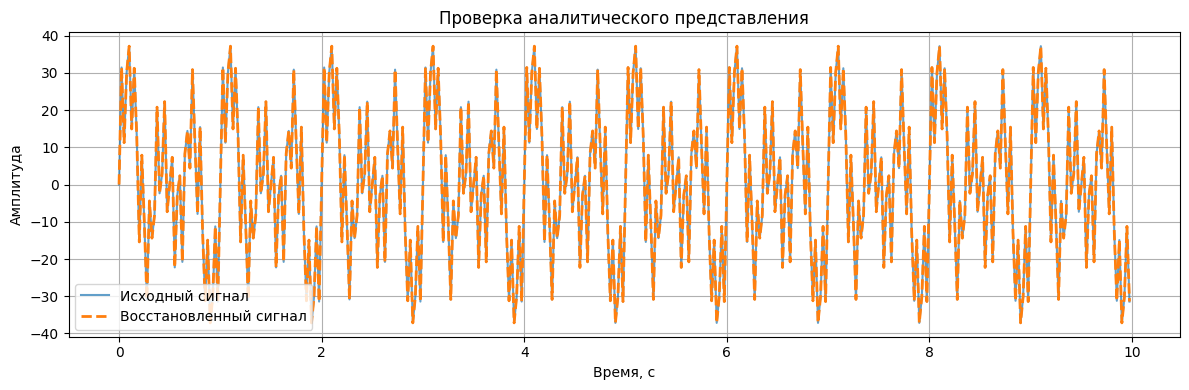


Оценка ошибки восстановления:
Максимальная ошибка: 0.000000
Средняя абсолютная ошибка: 0.000000
Среднеквадратичная ошибка: 0.000000
Рисунок сохранён: figures_lab3/signal_reconstruction_error.png


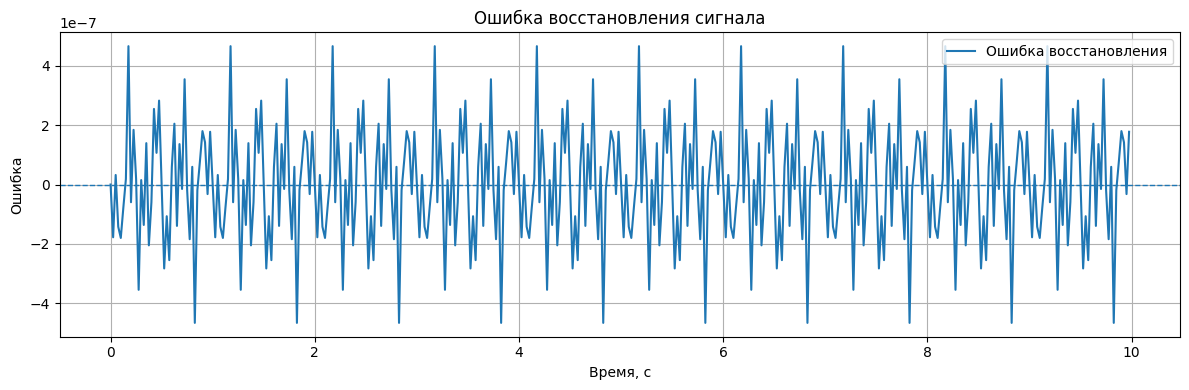

In [3]:
# ------------------------------------------------------------
# Поиск основных гармоник
# ------------------------------------------------------------

# Порог значимых гармоник
threshold = np.max(amp) * 0.05

peak_indices = []

# Ищем локальные максимумы вручную
for i in range(1, len(amp)-1):

    if amp[i] > threshold:
        if amp[i] > amp[i-1] and amp[i] > amp[i+1]:
            peak_indices.append(i)

# Параметры гармоник
peak_freqs = freqs[peak_indices]
peak_amps = amp[peak_indices]
peak_phases_cos = phase[peak_indices]

# Переход:
# A*cos(wt + φ) = A*sin(wt + φ + 90°)
peak_phases_sin = peak_phases_cos + 90

# ------------------------------------------------------------
# Вывод аналитического выражения
# ------------------------------------------------------------

terms = []

for f, A, p in zip(peak_freqs, peak_amps, peak_phases_sin):

    term = f"{A:.2f}·sin(2π·{f:.2f}·t + {p:.1f}°)"
    terms.append(term)

signal_equation = " + ".join(terms)

print("Аналитическое представление сигнала:\n")
print("x(t) =", signal_equation)

# ------------------------------------------------------------
# Восстановление сигнала
# ------------------------------------------------------------

reconstructed = np.zeros(N)

for f, A, phi in zip(peak_freqs,
                      peak_amps,
                      peak_phases_sin):

    reconstructed += A * np.sin(
        2 * np.pi * f * t +
        np.deg2rad(phi)
    )

# ------------------------------------------------------------
# Сравнение сигналов
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 4))

plt.plot(t,
         data,
         label='Исходный сигнал',
         alpha=0.7)

plt.plot(t,
         reconstructed,
         '--',
         linewidth=2,
         label='Восстановленный сигнал')

plt.title('Проверка аналитического представления')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')

plt.grid(True)
plt.legend()

plt.tight_layout()

save_figure(fig, "signal_reconstruction")

plt.show()

error = data - reconstructed

max_error = np.max(np.abs(error))
mean_error = np.mean(np.abs(error))
mse_error = np.mean(error**2)

print("\nОценка ошибки восстановления:")
print(f"Максимальная ошибка: {max_error:.6f}")
print(f"Средняя абсолютная ошибка: {mean_error:.6f}")
print(f"Среднеквадратичная ошибка: {mse_error:.6f}")

fig = plt.figure(figsize=(12, 4))

plt.plot(t,
         error,
         label='Ошибка восстановления',
         linewidth=1.5)

plt.axhline(0,
            linestyle='--',
            linewidth=1)

plt.title('Ошибка восстановления сигнала')
plt.xlabel('Время, с')
plt.ylabel('Ошибка')

plt.grid(True)
plt.legend()

plt.tight_layout()

save_figure(fig, "signal_reconstruction_error")

plt.show()

## 3. Нестационарный сигнал и вейвлет-анализ

Для моделирования сигнала с изменяющимися во времени частотами каждой гармонике задаётся свой временной интервал активности.  
Непрерывное вейвлет-преобразование (CWT) переводит сигнал в частотно-временную область:

$$T(a,b) = \frac{1}{\sqrt{a}} \int_{-\infty}^{\infty} x(t)\, \psi^*\!\left(\frac{t-b}{a}\right) dt,$$

где $a$ – масштаб (обратно пропорционален частоте), $b$ – сдвиг, $\psi$ – материнский вейвлет.  
Результат (скалограмма) визуализирует, как меняется спектральный состав со временем.  
Ниже сравниваются спектры и скалограммы исходного (стационарного) и модифицированного сигналов.

Рисунок сохранён: figures_lab3/stationary_and_local_signal.png


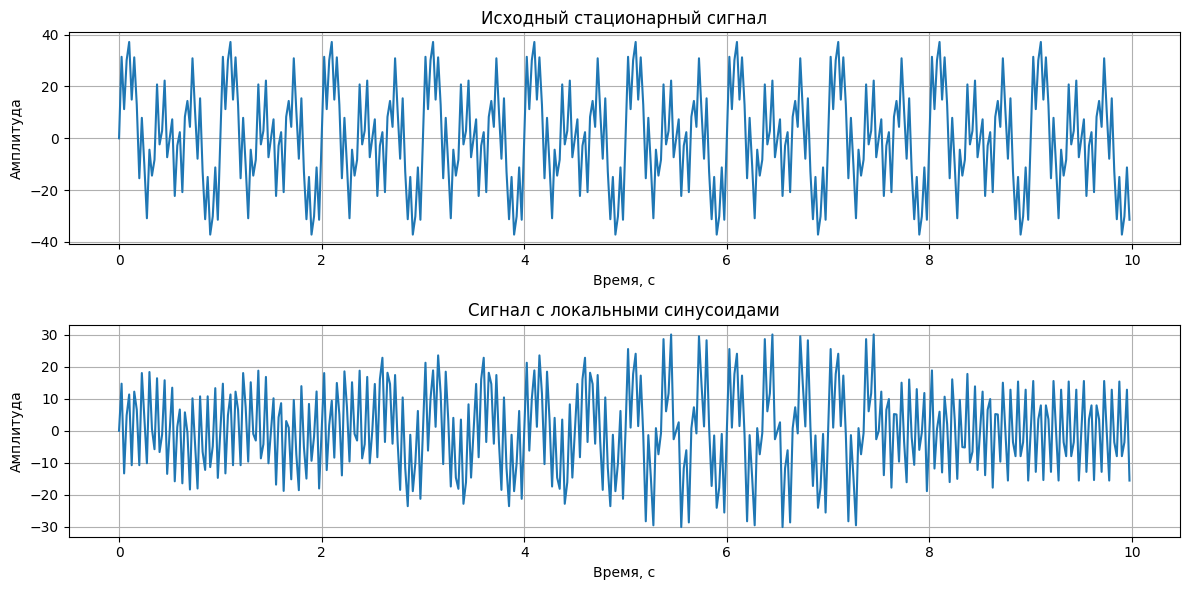

Рисунок сохранён: figures_lab3/wavelet_scalograms.png


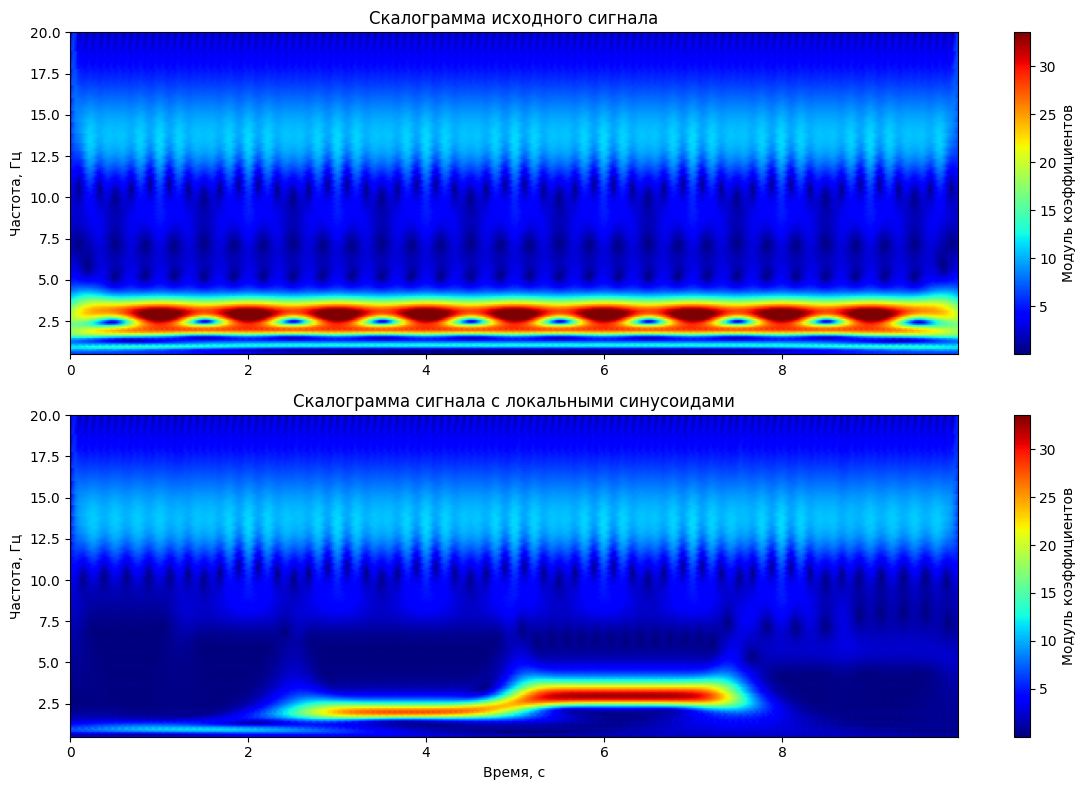

In [4]:
# ------------------------------------------------------------
# Сигнал с локальными синусоидами
# ------------------------------------------------------------

mod_signal = np.zeros(N)

windows = [
    (0, N//4),
    (N//4, N//2),
    (N//2, 3*N//4),
    (3*N//4, N),
    (N//8, 7*N//8)
]

for i, (f, A, phi_s) in enumerate(zip(peak_freqs,
                                      peak_amps,
                                      peak_phases_sin)):

    if i < len(windows):
        s, e = windows[i]

        mod_signal[s:e] += A * np.sin(
            2 * np.pi * f * t[s:e] +
            np.deg2rad(phi_s)
        )

    else:
        mod_signal += A * np.sin(
            2 * np.pi * f * t +
            np.deg2rad(phi_s)
        )

# ------------------------------------------------------------
# Сравнение сигналов во времени
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, data)
plt.title('Исходный стационарный сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, mod_signal)
plt.title('Сигнал с локальными синусоидами')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()

save_figure(fig, "stationary_and_local_signal")

plt.show()

# ------------------------------------------------------------
# Вейвлет-преобразование
# ------------------------------------------------------------

dt = t[1] - t[0]

wavelet = 'cmor1.5-1.0'

# Частоты, которые хотим увидеть на скалограмме
target_freqs = np.linspace(0.5, 20, 200)

# Перевод частот в масштабы для выбранного вейвлета
central_freq = pywt.central_frequency(wavelet)
scales = central_freq / (target_freqs * dt)

coeff_orig, freqs_cwt = pywt.cwt(
    data,
    scales,
    wavelet,
    sampling_period=dt
)

coeff_mod, _ = pywt.cwt(
    mod_signal,
    scales,
    wavelet,
    sampling_period=dt
)

pow_orig = np.abs(coeff_orig)
pow_mod = np.abs(coeff_mod)

# ------------------------------------------------------------
# Скалограммы
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)

plt.imshow(
    pow_orig,
    extent=[t[0], t[-1], freqs_cwt[0], freqs_cwt[-1]],
    origin='lower',
    aspect='auto',
    cmap='jet',
    vmax=np.percentile(pow_orig, 99)
)

plt.title('Скалограмма исходного сигнала')
plt.ylabel('Частота, Гц')
plt.colorbar(label='Модуль коэффициентов')
plt.grid(False)

plt.subplot(2, 1, 2)

plt.imshow(
    pow_mod,
    extent=[t[0], t[-1], freqs_cwt[0], freqs_cwt[-1]],
    origin='lower',
    aspect='auto',
    cmap='jet',
    vmax=np.percentile(pow_orig, 99)
)

plt.title('Скалограмма сигнала с локальными синусоидами')
plt.xlabel('Время, с')
plt.ylabel('Частота, Гц')
plt.colorbar(label='Модуль коэффициентов')
plt.grid(False)

plt.tight_layout()

save_figure(fig, "wavelet_scalograms")

plt.show()

## 4. Режекторные фильтры варианта 3

Режектор должен подавлять выбранную полосу и сохранять компоненты вне этой полосы. В качестве демонстрационной подавляемой полосы используется область около выраженной гармоники 14 Гц. Параметры можно изменить в ячейке ниже.

### 4.1 Ручной КИХ-режектор с окном Блэкмана

Идеальная импульсная характеристика режектора строится как

$$h_{bs}[n]=\delta[n-M]-\left(h_{lp}(f_2)[n]-h_{lp}(f_1)[n]\right),$$

где

$$h_{lp}(f_c)[n]=\begin{cases}2f_c/f_s,& n=M,\\ \frac{\sin(2\pi f_c(n-M)/f_s)}{\pi(n-M)},& n\neq M.\end{cases}$$

Затем применяется окно Блэкмана

$$w[n]=0.42-0.5\cos\frac{2\pi n}{L-1}+0.08\cos\frac{4\pi n}{L-1}.$$

In [5]:
# ------------------------------------------------------------
# Проектирование КИХ-режектора с окном Блэкмана
# ------------------------------------------------------------

def fir_bandstop_blackman(f0, bw, fs, numtaps=61):

    n = np.arange(numtaps)
    alpha = (numtaps - 1) / 2

    f1 = f0 - bw / 2
    f2 = f0 + bw / 2

    h = np.zeros(numtaps)

    for i in range(numtaps):

        m = i - alpha

        if m == 0:
            h[i] = 1 - 2 * (f2 - f1) / fs
        else:
            h_lowpass_2 = np.sin(2 * np.pi * f2 * m / fs) / (np.pi * m)
            h_lowpass_1 = np.sin(2 * np.pi * f1 * m / fs) / (np.pi * m)

            # режектор = единичный импульс - полосовой фильтр
            h[i] = h_lowpass_1 - h_lowpass_2

    # добавляем единичный импульс в центр
    h[int(alpha)] += 1

    # Окно Блэкмана
    win = (
        0.42
        - 0.5 * np.cos(2 * np.pi * n / (numtaps - 1))
        + 0.08 * np.cos(4 * np.pi * n / (numtaps - 1))
    )

    return h * win, win


# Параметры КИХ-фильтра
f0_fir = 5.0
bw_fir = 0.8
numtaps_fir = 61

b_fir, blackman_win = fir_bandstop_blackman(
    f0=f0_fir,
    bw=bw_fir,
    fs=fs,
    numtaps=numtaps_fir
)

a_fir = [1.0]

print("Количество коэффициентов КИХ-фильтра:", len(b_fir))
print("Центральная частота режекции:", f0_fir, "Гц")
print("Ширина полосы режекции:", bw_fir, "Гц")

Количество коэффициентов КИХ-фильтра: 61
Центральная частота режекции: 5.0 Гц
Ширина полосы режекции: 0.8 Гц


Рисунок сохранён: figures_lab3/fir_blackman_window.png


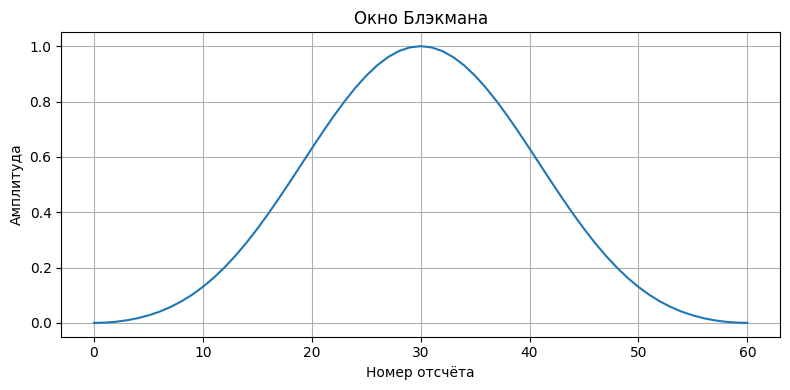

In [6]:
# ------------------------------------------------------------
# Окно Блэкмана
# ------------------------------------------------------------

fig = plt.figure(figsize=(8, 4))

plt.plot(blackman_win)
plt.title('Окно Блэкмана')
plt.xlabel('Номер отсчёта')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()

save_figure(fig, "fir_blackman_window")

plt.show()

Рисунок сохранён: figures_lab3/fir_blackman_response.png


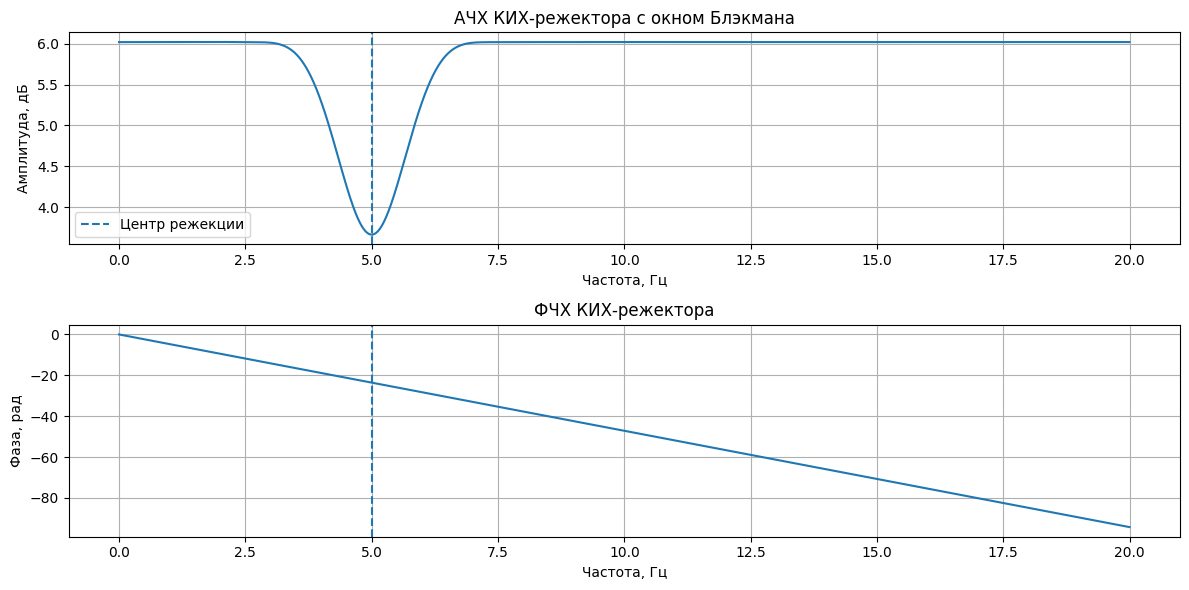

КИХ ручная фильтрация: 3559.2 мкс


In [7]:
# ------------------------------------------------------------
# АЧХ и ФЧХ КИХ-фильтра
# ------------------------------------------------------------

w_fir, h_fir = freqz(
    b_fir,
    a_fir,
    worN=8000,
    fs=fs
)

amp_fir_db = 20 * np.log10(np.abs(h_fir) + 1e-12)
phase_fir = np.unwrap(np.angle(h_fir))

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(w_fir, amp_fir_db)
plt.axvline(f0_fir, linestyle='--', label='Центр режекции')
plt.title('АЧХ КИХ-режектора с окном Блэкмана')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда, дБ')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(w_fir, phase_fir)
plt.axvline(f0_fir, linestyle='--')
plt.title('ФЧХ КИХ-режектора')
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.grid(True)

plt.tight_layout()

save_figure(fig, "fir_blackman_response")

plt.show()

# ------------------------------------------------------------
# Ручная фильтрация КИХ-фильтром
# ------------------------------------------------------------

start = time.perf_counter()

def manual_filter(b, a, x):

    M = len(b)
    K = len(a)

    y = np.zeros(len(x))

    for n in range(len(x)):

        for i in range(M):
            if n - i >= 0:
                y[n] += b[i] * x[n - i]

        for j in range(1, K):
            if n - j >= 0:
                y[n] -= a[j] * y[n - j]

        y[n] /= a[0]

    return y


y_fir = manual_filter(
    b_fir,
    a_fir,
    data
)

time_fir = time.perf_counter() - start

print(f"КИХ ручная фильтрация: {time_fir * 1e6:.1f} мкс")

### 4.2 БИХ-фильтр Чебышёва 1-го рода (режекторный)

Чебышёвский фильтр типа I имеет равномерные пульсации в полосе пропускания и монотонный спад в полосе заграждения.  
Для режекторного фильтра сначала проектируется аналоговый ФНЧ-прототип, затем с помощью частотного преобразования и билинейного $z$-преобразования получаются коэффициенты цифрового фильтра.  

Нормированный аналоговый ФНЧ-прототип первого порядка:

$$H_{lp}(s)=\frac{p}{s+p},\qquad p=\frac{1}{\varepsilon}.$$

Переход к аналоговому режектору выполняется заменой

$$s_{lp}=\frac{B s}{s^2+\Omega_0^2},$$

где $\Omega_1=2f_s\tan(\pi f_1/f_s)$, $\Omega_2=2f_s\tan(\pi f_2/f_s)$, $B=\Omega_2-\Omega_1$, $\Omega_0=\sqrt{\Omega_1\Omega_2}$. После этого применяется билинейная подстановка

$$s=2f_s\frac{1-z^{-1}}{1+z^{-1}}.$$

Итоговые коэффициенты получаются с помощью `scipy.signal.cheby1`

Коэффициенты БИХ-фильтра:
b: [ 0.97324415 -1.3806311   0.97324415]
a: [ 1.        -1.3806311  0.9464883]
Рисунок сохранён: figures_lab3/iir_cheby1_response.png


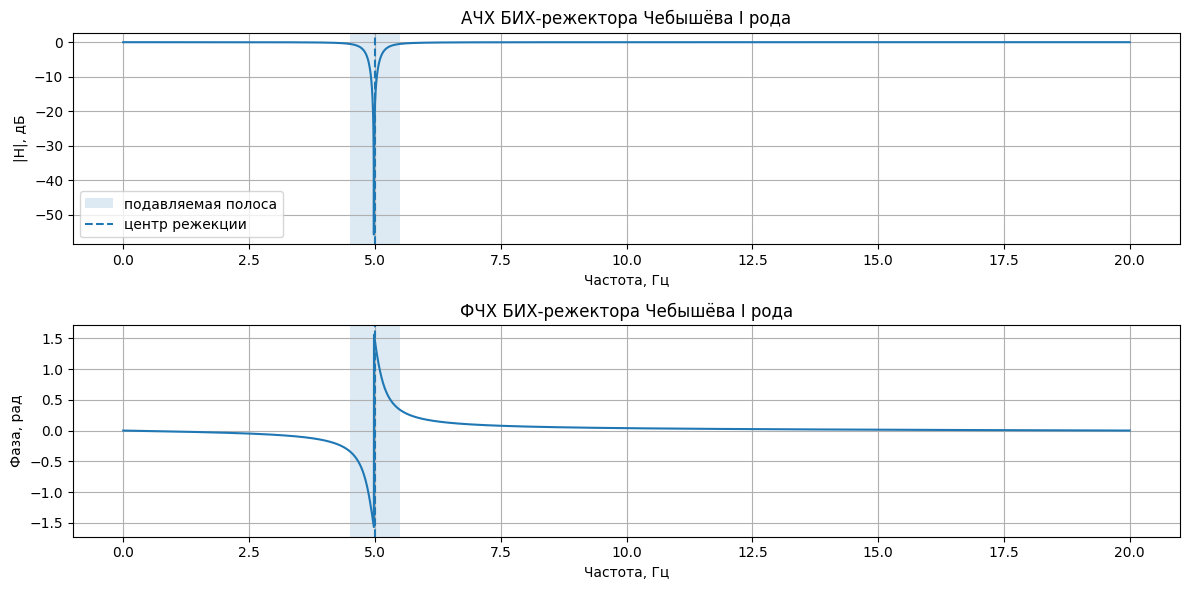

In [8]:
def manual_filter(b, a, x):

    M = len(b)
    K = len(a)

    y = np.zeros(len(x))

    for n in range(len(x)):

        for i in range(M):
            if n - i >= 0:
                y[n] += b[i] * x[n - i]

        for j in range(1, K):
            if n - j >= 0:
                y[n] -= a[j] * y[n - j]

        y[n] /= a[0]

    return y

# ------------------------------------------------------------
# БИХ-фильтр Чебышёва I рода, режекторный
# ------------------------------------------------------------



f0_iir = 5.0
bw_iir = 1.0

f1_iir = f0_iir - bw_iir / 2
f2_iir = f0_iir + bw_iir / 2

order_iir = 1
ripple_iir = 0.5

b_iir, a_iir = cheby1(
    order_iir,
    ripple_iir,
    [f1_iir, f2_iir],
    btype='bandstop',
    fs=fs
)

print("Коэффициенты БИХ-фильтра:")
print("b:", b_iir)
print("a:", a_iir)

# ------------------------------------------------------------
# АЧХ и ФЧХ БИХ-фильтра
# ------------------------------------------------------------

w_iir, h_iir = freqz(
    b_iir,
    a_iir,
    worN=8000,
    fs=fs
)

amp_iir_db = 20 * np.log10(np.abs(h_iir) + 1e-12)
phase_iir = np.unwrap(np.angle(h_iir))

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(w_iir, amp_iir_db)

plt.axvspan(
    f1_iir,
    f2_iir,
    alpha=0.15,
    label='подавляемая полоса'
)

plt.axvline(
    f0_iir,
    linestyle='--',
    label='центр режекции'
)

plt.title('АЧХ БИХ-режектора Чебышёва I рода')
plt.xlabel('Частота, Гц')
plt.ylabel('|H|, дБ')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(w_iir, phase_iir)

plt.axvspan(
    f1_iir,
    f2_iir,
    alpha=0.15
)

plt.axvline(
    f0_iir,
    linestyle='--'
)

plt.title('ФЧХ БИХ-режектора Чебышёва I рода')
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.grid(True)

plt.tight_layout()

save_figure(fig, "iir_cheby1_response")

plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Нули БИХ-фильтра:
[0.7092933+0.70491348j 0.7092933-0.70491348j]

Полюса БИХ-фильтра:
[0.69031555+0.68553099j 0.69031555-0.68553099j]

Модули полюсов:
[0.9728763 0.9728763]
Фильтр устойчив: все полюса находятся внутри единичной окружности.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Рисунок сохранён: figures_lab3/iir_cheby1_zero_pole_map.png


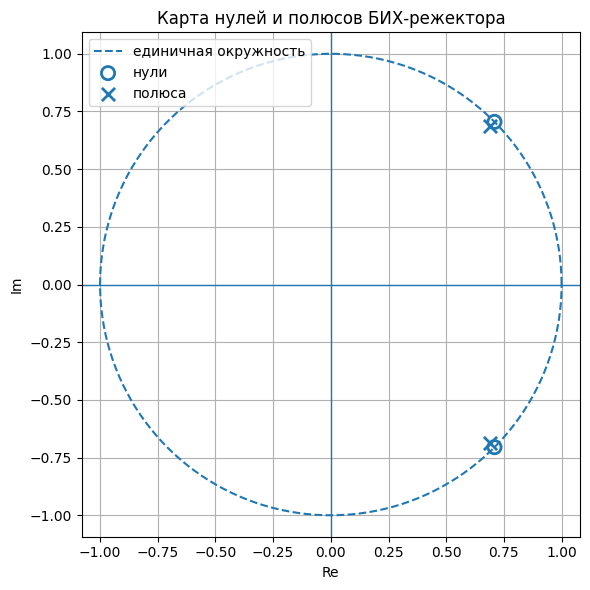

In [9]:
# ------------------------------------------------------------
# Карта нулей и полюсов БИХ-фильтра
# ------------------------------------------------------------

zeros_iir = np.roots(b_iir)
poles_iir = np.roots(a_iir)

print("Нули БИХ-фильтра:")
print(zeros_iir)

print("\nПолюса БИХ-фильтра:")
print(poles_iir)

print("\nМодули полюсов:")
print(np.abs(poles_iir))

if np.all(np.abs(poles_iir) < 1):
    print("Фильтр устойчив: все полюса находятся внутри единичной окружности.")
else:
    print("Фильтр неустойчив: есть полюса вне единичной окружности.")

theta = np.linspace(0, 2 * np.pi, 500)

fig = plt.figure(figsize=(6, 6))

plt.plot(
    np.cos(theta),
    np.sin(theta),
    linestyle='--',
    label='единичная окружность'
)

plt.scatter(
    np.real(zeros_iir),
    np.imag(zeros_iir),
    marker='o',
    s=90,
    facecolors='none',
    edgecolors='C0',
    linewidths=2,
    label='нули'
)

plt.scatter(
    np.real(poles_iir),
    np.imag(poles_iir),
    marker='x',
    s=90,
    linewidths=2,
    label='полюса'
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title('Карта нулей и полюсов БИХ-режектора')
plt.xlabel('Re')
plt.ylabel('Im')

plt.grid(True)
plt.axis('equal')

# Немного расширяем область, чтобы точки у правого края не слипались с рамкой
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.legend(loc='upper left')

plt.tight_layout()

save_figure(fig, "iir_cheby1_zero_pole_map")

plt.show()

In [10]:
# ------------------------------------------------------------
# Ручная фильтрация БИХ-фильтром
# ------------------------------------------------------------

start = time.perf_counter()

y_iir = manual_filter(
    b_iir,
    a_iir,
    data
)

time_iir = time.perf_counter() - start

print(f"БИХ ручная фильтрация: {time_iir * 1e6:.1f} мкс")

БИХ ручная фильтрация: 420.0 мкс


### 4.3 Сравнение результатов фильтрации

Ниже показаны временны́е реализации исходного и отфильтрованных сигналов, а также время обработки каждым фильтром.

Рисунок сохранён: figures_lab3/filtering_comparison_time.png


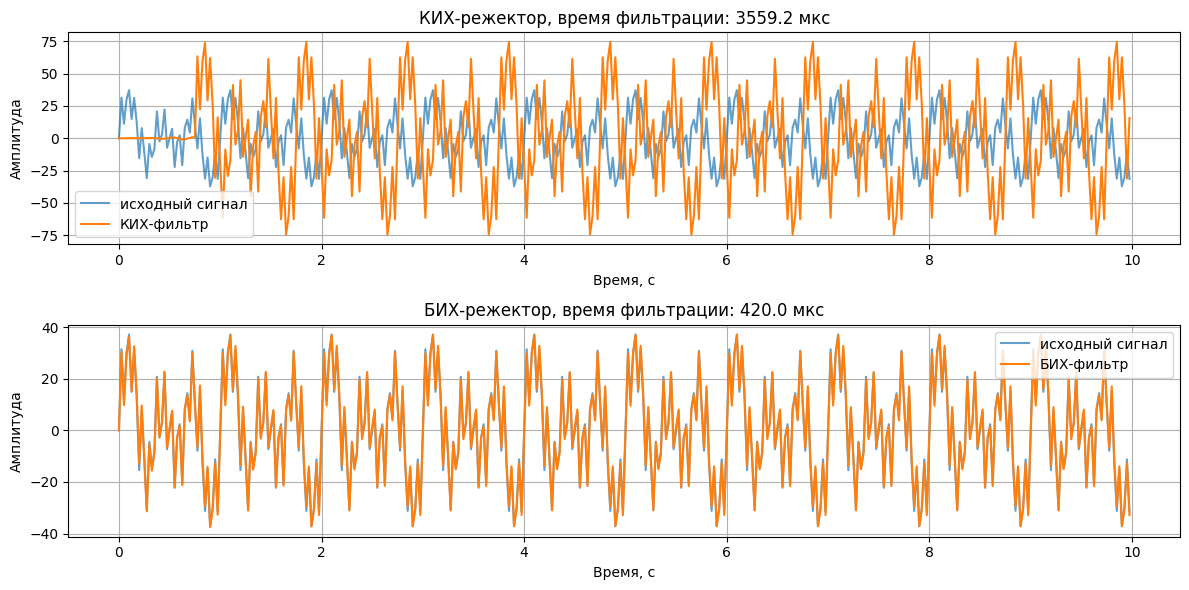

Время КИХ: 3559.2 мкс
Время БИХ: 420.0 мкс


In [11]:
# ------------------------------------------------------------
# Визуализация и сравнение результатов фильтрации
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

plt.plot(t,
         data,
         alpha=0.7,
         label='исходный сигнал')

plt.plot(t,
         y_fir,
         label='КИХ-фильтр')

plt.title(f'КИХ-режектор, время фильтрации: {time_fir * 1e6:.1f} мкс')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)

plt.plot(t,
         data,
         alpha=0.7,
         label='исходный сигнал')

plt.plot(t,
         y_iir,
         label='БИХ-фильтр')

plt.title(f'БИХ-режектор, время фильтрации: {time_iir * 1e6:.1f} мкс')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()

plt.tight_layout()

save_figure(fig, "filtering_comparison_time")

plt.show()

print(f"Время КИХ: {time_fir * 1e6:.1f} мкс")
print(f"Время БИХ: {time_iir * 1e6:.1f} мкс")

## 5. Оценка средней частоты сердечных сокращений (ЧСС)

Пункт 5а: по зашумлённой записи ЭКГ требуется определить среднюю ЧСС. 
Для надежного выделения пиков на фоне шумов и дрейфа изолинии применяется метод, основанный на алгоритме Пана-Томпкинса. 

Основные шаги алгоритма:

1. Применение полосового фильтра для подавления высокочастотных шумов и низкочастотного дрейфа базовой линии (обычно в полосе 5–15 Гц).
2. Возведение сигнала в квадрат для усиления полезного сигнала (R-зубцов) и подавления ложных всплесков.
3. Поиск пиков (`find_peaks`) с учетом физиологических ограничений на минимальный интервал между сердечными сокращениями.
4. Расчет средней ЧСС по формуле:

$$\text{ЧСС} = \frac{60 \cdot f_s}{RR_{\text{отсчеты}}}$$

где $RR_{\text{ср}}$ — среднее расстояние между соседними R-пиками в отсчетах, а $f_s$ — частота дискретизации.

In [12]:
# ------------------------------------------------------------
# Импорт библиотек и загрузка ЭКГ
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, freqz
from pathlib import Path

FIG_DIR = Path("figures_lab3")
FIG_DIR.mkdir(exist_ok=True)

def save_figure(fig, name, dpi=300):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"Рисунок сохранён: {FIG_DIR / (name + '.png')}")


# Параметры сигнала
fs = 360
T = 1 / fs

ecg = np.loadtxt('signal_ecg_3.txt')

N = len(ecg)
t = np.arange(N) * T
duration = N * T

print(f"Загружено отсчётов: {N}")
print(f"Длительность сигнала: {duration:.2f} с")
print(f"Частота дискретизации: {fs} Гц")

Загружено отсчётов: 3600
Длительность сигнала: 10.00 с
Частота дискретизации: 360 Гц


Рисунок сохранён: figures_lab3/ecg_bandpass_response.png


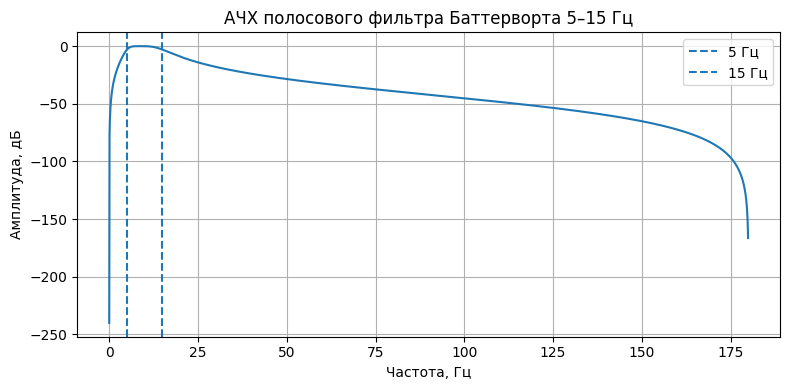

In [13]:
# ------------------------------------------------------------
# Полосовой фильтр Баттерворта 5–15 Гц
# ------------------------------------------------------------

order = 2
lowcut = 5.0
highcut = 15.0

nyquist = fs / 2

low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(
    order,
    [low, high],
    btype='band',
    analog=False
)

w, h = freqz(
    b,
    a,
    worN=2000,
    fs=fs
)

fig = plt.figure(figsize=(8, 4))

plt.plot(w, 20 * np.log10(np.abs(h) + 1e-12))
plt.axvline(lowcut, linestyle='--', label='5 Гц')
plt.axvline(highcut, linestyle='--', label='15 Гц')

plt.title('АЧХ полосового фильтра Баттерворта 5–15 Гц')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда, дБ')
plt.grid(True)
plt.legend()

plt.tight_layout()

save_figure(fig, "ecg_bandpass_response")

plt.show()

Рисунок сохранён: figures_lab3/ecg_filtered_signal.png


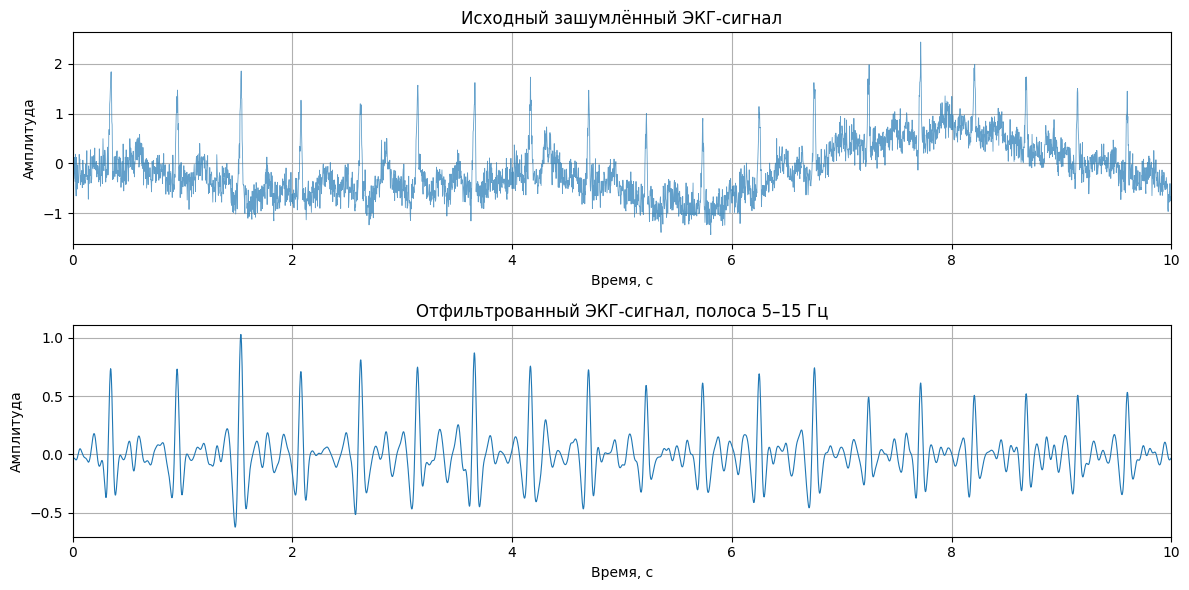

In [14]:
# ------------------------------------------------------------
# Фильтрация ЭКГ
# ------------------------------------------------------------

ecg_filtered = filtfilt(
    b,
    a,
    ecg
)

fig = plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

plt.plot(
    t,
    ecg,
    linewidth=0.6,
    alpha=0.7
)

plt.title('Исходный зашумлённый ЭКГ-сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, duration)

plt.subplot(2, 1, 2)

plt.plot(
    t,
    ecg_filtered,
    linewidth=0.8
)

plt.title('Отфильтрованный ЭКГ-сигнал, полоса 5–15 Гц')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, duration)

plt.tight_layout()

save_figure(fig, "ecg_filtered_signal")

plt.show()

In [15]:
# ------------------------------------------------------------
# Поиск R-пиков
# ------------------------------------------------------------

# 1. Производная подчёркивает резкие фронты QRS-комплексов
ecg_derivative = np.diff(ecg_filtered, prepend=ecg_filtered[0])

# 2. Квадрат усиливает большие отклонения
ecg_squared = ecg_derivative ** 2

# 3. Скользящее интегрирование
window_size = int(0.12 * fs)

integration_window = np.ones(window_size) / window_size

ecg_integrated = np.convolve(
    ecg_squared,
    integration_window,
    mode='same'
)

# 4. Порог поиска кандидатов
threshold = np.mean(ecg_integrated) + 0.7 * np.std(ecg_integrated)

# Минимальное расстояние между соседними R-пиками
# 0.3 с соответствует ЧСС до 200 уд/мин
min_distance = int(0.3 * fs)

candidate_peaks, properties = find_peaks(
    ecg_integrated,
    height=threshold,
    distance=min_distance
)

# 5. Уточнение положения R-пиков на отфильтрованном сигнале
r_peaks = []

search_radius = int(0.08 * fs)

for peak in candidate_peaks:

    left = max(0, peak - search_radius)
    right = min(N, peak + search_radius)

    local_segment = ecg_filtered[left:right]

    if len(local_segment) > 0:
        local_peak = left + np.argmax(local_segment)
        r_peaks.append(local_peak)

r_peaks = np.array(r_peaks)

# Удаляем возможные дубли после уточнения
r_peaks = np.unique(r_peaks)

# ------------------------------------------------------------
# Расчёт ЧСС
# ------------------------------------------------------------

if len(r_peaks) >= 2:

    rr_intervals = np.diff(r_peaks)
    rr_mean = np.mean(rr_intervals)

    hr = 60 * fs / rr_mean

else:

    rr_intervals = np.array([])
    rr_mean = np.nan
    hr = np.nan

    print("Недостаточно пиков для расчёта ЧСС")


print("\nРезультаты обработки ЭКГ:")
print(f"Найдено R-пиков: {len(r_peaks)}")

if len(r_peaks) >= 2:
    print(f"Средний RR-интервал: {rr_mean:.2f} отсчётов")
    print(f"Средний RR-интервал: {rr_mean / fs * 1000:.1f} мс")
    print(f"Рассчитанная ЧСС: {hr:.1f} уд/мин")


Результаты обработки ЭКГ:
Найдено R-пиков: 18
Средний RR-интервал: 196.00 отсчётов
Средний RR-интервал: 544.4 мс
Рассчитанная ЧСС: 110.2 уд/мин


Рисунок сохранён: figures_lab3/ecg_peak_detection_steps.png


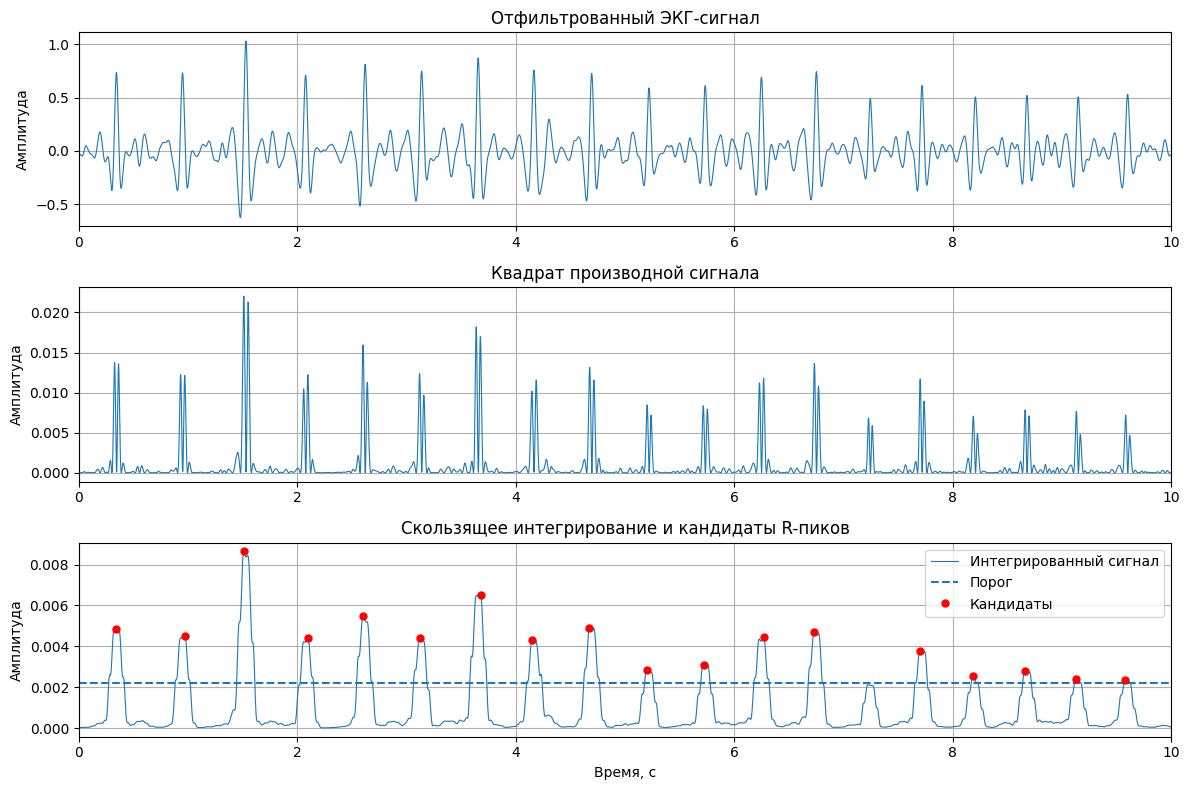

In [16]:
# ------------------------------------------------------------
# Визуализация промежуточных этапов поиска R-пиков
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)

plt.plot(
    t,
    ecg_filtered,
    linewidth=0.8
)

plt.title('Отфильтрованный ЭКГ-сигнал')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, duration)

plt.subplot(3, 1, 2)

plt.plot(
    t,
    ecg_squared,
    linewidth=0.8
)

plt.title('Квадрат производной сигнала')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, duration)

plt.subplot(3, 1, 3)

plt.plot(
    t,
    ecg_integrated,
    linewidth=0.8,
    label='Интегрированный сигнал'
)

plt.axhline(
    threshold,
    linestyle='--',
    label='Порог'
)

plt.plot(
    t[candidate_peaks],
    ecg_integrated[candidate_peaks],
    'ro',
    markersize=5,
    label='Кандидаты'
)

plt.title('Скользящее интегрирование и кандидаты R-пиков')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.xlim(0, duration)

plt.tight_layout()

save_figure(fig, "ecg_peak_detection_steps")

plt.show()

Рисунок сохранён: figures_lab3/ecg_r_peaks.png


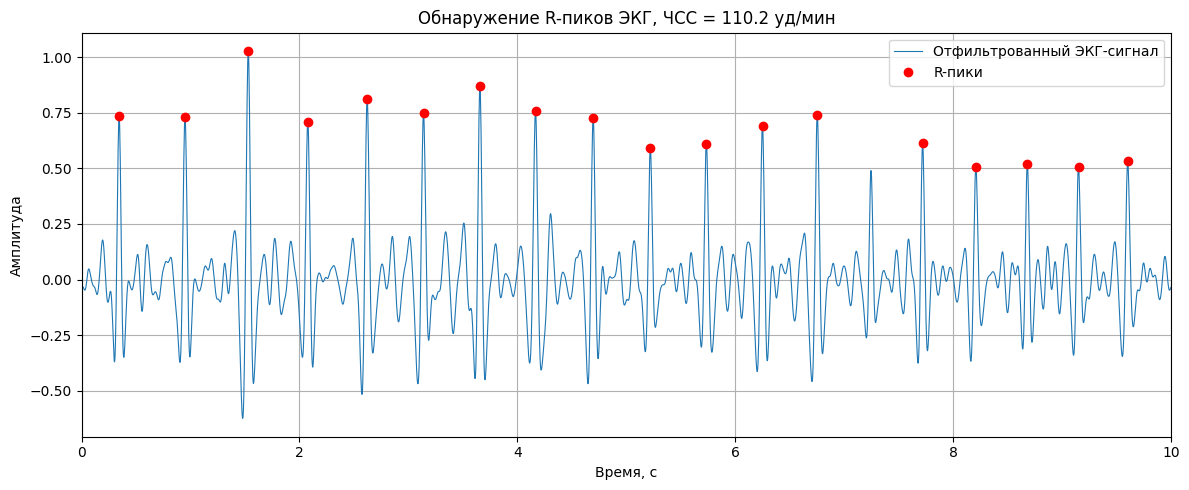

In [17]:
# ------------------------------------------------------------
# Визуализация найденных R-пиков
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 5))

plt.plot(
    t,
    ecg_filtered,
    label='Отфильтрованный ЭКГ-сигнал',
    linewidth=0.8
)

plt.plot(
    t[r_peaks],
    ecg_filtered[r_peaks],
    'ro',
    label='R-пики',
    markersize=6
)

plt.title(f'Обнаружение R-пиков ЭКГ, ЧСС = {hr:.1f} уд/мин')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.xlim(0, duration)

plt.tight_layout()

save_figure(fig, "ecg_r_peaks")

plt.show()